# $ \text{Т.13} $

$ \text{Исследование длины и ширины 139 черепов,} \\ \text{ найденных в Верхнем Египте и относимых к расе,} \\ \text{ жившей за 8000 лет до нашей эры, показало,} \\ \text{ что стандартное отклонение длины и ширины черепа} \\ \text{ 5.722 и 4.612 мм соответственно. Те же величины,} \\ \text{ выведенные на основании обследования 1000 европейцев,} \\ \text{ оказались равными 6.161 и 5.055 мм.} $



Египетские черепа ($n=139$):  
$s_{дл}=5.722$, $s_{шир}=4.612$ (стандартные отклонения)  

Европейцы ($m=1000$):  
$s_{дл}=6.161$, $s_{шир}=5.055$

Предполагается нормальность распределений. Проверяется гипотеза о равенстве дисперсий (для длины и для ширины отдельно).

#### Критерий Фишера

$$
H_0: \sigma_1^2 = \sigma_2^2,\qquad H_1: \sigma_1^2 \neq \sigma_2^2
$$

Статистика:  
$$
F = \frac{S_1^2}{S_2^2} \sim F(n-1,\; m-1) \quad \text{при } H_0
$$

Критическая область (уровень $\alpha$):  
$$
G:\; F < F_{\alpha/2}(n-1,m-1) \;\; \text{или}\;\; F > F_{1-\alpha/2}(n-1,m-1)
$$

Мощность критерия при альтернативе $\lambda = \sigma_1^2/\sigma_2^2$:  
$$
W(\lambda) = P\left(F < F_{\alpha/2}\mid \lambda\right) + P\left(F > F_{1-\alpha/2}\mid \lambda\right),
$$
где $F \sim \lambda \cdot F(n-1,m-1)$.

#### Вычисления

Для длины:  
$S_1^2 = 5.722^2 = 32.74$, $S_2^2 = 6.161^2 = 37.96$  
$F_{\text{набл}} = 32.74/37.96 = 0.862$

Для ширины:  
$S_1^2 = 4.612^2 = 21.27$, $S_2^2 = 5.055^2 = 25.55$  
$F_{\text{набл}} = 21.27/25.55 = 0.832$

При $\alpha=0.05$:  
$F_{0.025}(138,999) \approx 0.77$, $F_{0.975}(138,999) \approx 1.27$

Оба наблюдаемых значения попадают в интервал $(0.80; 1.25)$, следовательно, $H_0$ не отвергается

### $$ \alpha = 0.05 $$

In [1]:
from rich.console import Console
from rich.panel import Panel
from rich.text import Text

import scipy.stats as stats

import numpy as np
import matplotlib.pyplot as polt
from matplotlib.ticker import AutoMinorLocator

console = Console()

In [2]:
alpha = 0.05
n = 139
m = 1000

In [3]:
quantile_alpha_2 = stats.f.ppf(alpha / 2, n - 1, m - 1)

console.print(Panel(Text(str(quantile_alpha_2), style="bold"),
              title="Квантиль порядка alpha/2"),
              justify="left")

╭─ Квантиль порядка alpha/2 ─╮                                                                                     
│ 0.7673823155977318         │                                                                                     
╰────────────────────────────╯

In [4]:
quantile_1_minus_alpha_2 = stats.f.ppf(1 - alpha / 2, n - 1, m - 1)

console.print(Panel(Text(str(quantile_1_minus_alpha_2), style="bold"),
              title="Квантиль порядка 1 - alpha/2"),
              justify="left")

╭─ Квантиль порядка 1 - alpha/2 ─╮                                                                                 
│ 1.271697073036989              │                                                                                 
╰────────────────────────────────╯

In [5]:
Sx_length, Sy_length = 5.722, 6.161
Sx_width, Sy_width = 4.612, 5.055

In [7]:
delta_length = Sx_length ** 2 / Sy_length ** 2

console.print(Panel(Text(str(delta_length), style="bold"),
              title="Значение delta для длины"),
              justify="left")

╭─ Значение delta для длины ─╮                                                                                     
│ 0.8625678945904338         │                                                                                     
╰────────────────────────────╯

In [8]:
delta_width = Sx_width ** 2 / Sy_width ** 2

console.print(Panel(Text(str(delta_width), style="bold"),
              title="Значение delta для ширины"),
              justify="left")

╭─ Значение delta для ширины ─╮                                                                                    
│ 0.8324080612765026          │                                                                                    
╰─────────────────────────────╯

## $ \text{1) Построить график мощности критерия.} $

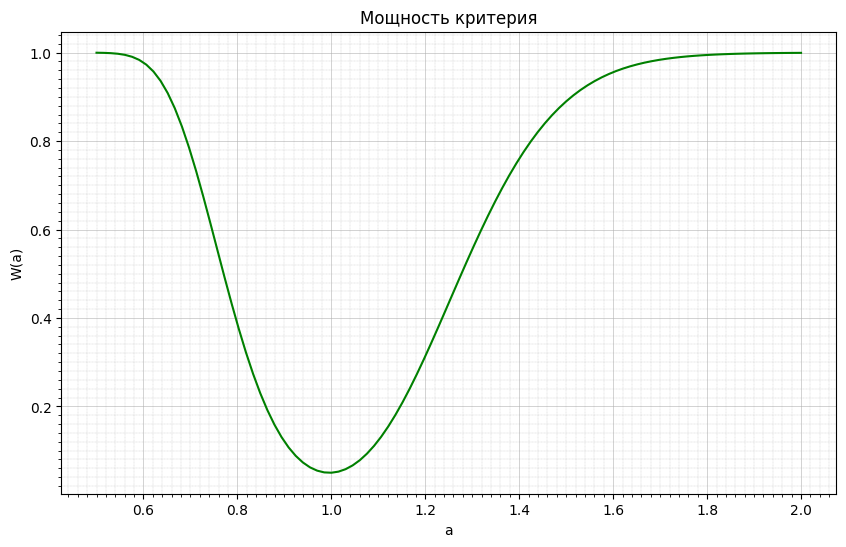

In [9]:
_, axs = polt.subplots(1, 1, figsize=(10, 6))

axs.set_title("Мощность критерия")
axs.set_xlabel("a")
axs.set_ylabel("W(a)")

a = np.linspace(0.5, 2, 100)

axs.plot(a, 1 - stats.f.cdf(quantile_1_minus_alpha_2, n - 1, m - 1, scale=a) +
         stats.f.cdf(quantile_alpha_2, n - 1, m - 1, scale=a), color="green")

axs.xaxis.set_minor_locator(AutoMinorLocator(10))
axs.yaxis.set_minor_locator(AutoMinorLocator(10))

polt.grid(which='minor', linestyle='--', linewidth=0.2)
polt.grid(which='major', linewidth=0.4)

# polt.legend()
polt.show()